## `RainFall Prediction Analysis`

### `Importing Libraries`

In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import  StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score, auc, roc_curve, roc_auc_score, roc_curve, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay


from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

### `Importing and Reading Dataset`

In [113]:
rainfall = pd.read_csv('../Dataset/Rainfall.csv')

rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7


### `Summary Statistics`

In [114]:
rainfall.describe()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,365.000000,365.000000
mean,15.756831,1013.742623,26.191257,23.747268,21.894536,19.989071,80.177596,71.128415,4.419399,101.506849,21.536986
std,8.823592,6.414776,5.978343,5.632813,5.594153,5.997021,10.062470,21.798012,3.934398,81.723724,10.069712
min,1.000000,998.500000,7.100000,4.900000,3.100000,-0.400000,36.000000,0.000000,0.000000,10.000000,4.400000
25%,8.000000,1008.500000,21.200000,18.825000,17.125000,16.125000,75.000000,58.000000,0.500000,40.000000,13.700000
50%,16.000000,1013.000000,27.750000,25.450000,23.700000,21.950000,80.500000,80.000000,3.500000,70.000000,20.500000
75%,23.000000,1018.100000,31.200000,28.600000,26.575000,25.000000,87.000000,88.000000,8.200000,190.000000,27.900000
max,31.000000,1034.600000,36.300000,32.400000,30.000000,26.700000,98.000000,100.000000,12.100000,350.000000,59.500000


In [115]:
rainfall.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB


### `Fixing Column Hidden Space`

In [116]:
rainfall.columns = rainfall.columns.str.strip().str.lower()
print(rainfall.columns)

Index(['day', 'pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity', 'cloud', 'rainfall', 'sunshine', 'winddirection',
       'windspeed'],
      dtype='object')


### `Feature Engineering`

In [117]:
rainfall['temp_humidity'] = rainfall['temparature'] * rainfall['humidity']
rainfall['dew_humidity'] = rainfall['dewpoint'] * rainfall['humidity']
rainfall['pressure_humidity'] = rainfall['pressure'] * rainfall['humidity']
rainfall['temp_range'] = rainfall['maxtemp'] - rainfall['mintemp']
rainfall['cloud_sunshine_ratio'] = rainfall['cloud'] / (rainfall['sunshine'] + 1)
rainfall['dew_temp_diff'] = rainfall['temparature'] - rainfall['dewpoint']

### `Handling Missing Values`

In [118]:
rainfall.isnull().sum().sort_values(ascending=False)

winddirection           1
windspeed               1
pressure                0
day                     0
maxtemp                 0
temparature             0
humidity                0
cloud                   0
mintemp                 0
dewpoint                0
sunshine                0
rainfall                0
temp_humidity           0
dew_humidity            0
pressure_humidity       0
temp_range              0
cloud_sunshine_ratio    0
dew_temp_diff           0
dtype: int64

### `Using Simple Imputer` to Handle Missing Value

In [119]:
imputer = SimpleImputer(strategy='median')

missing_col = rainfall.select_dtypes(include=[np.number])

for cols in missing_col:
    rainfall[cols] = imputer.fit_transform(rainfall[[cols]])

In [120]:
rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed,temp_humidity,dew_humidity,pressure_humidity,temp_range,cloud_sunshine_ratio,dew_temp_diff
0,1.0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,yes,9.3,80.0,26.3,1317.6,943.2,73864.8,3.1,4.757282,5.2
1,2.0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,yes,0.6,50.0,15.3,1530.9,1263.6,82782.0,4.5,51.875000,3.3
2,3.0,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,yes,0.0,40.0,14.2,1833.5,1748.0,96871.5,2.3,91.000000,0.9
3,4.0,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,yes,1.0,50.0,16.9,1854.0,1692.0,91701.0,3.2,44.000000,1.8
4,5.0,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,yes,0.0,40.0,13.7,1966.5,1890.5,96510.5,1.1,81.000000,0.8


### `Handling Outliers`

In [121]:
q1 = rainfall.select_dtypes(include=[np.number]).quantile(0.25)
q2 = rainfall.select_dtypes(include=[np.number]).quantile(0.75)

IQR = q2 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q2 + 1.5 * IQR

print('Lower Bound \n', lower_bound)
print('Upper Bound \n', upper_bound)

Lower Bound 
 day                       -14.500000
pressure                  994.100000
maxtemp                     6.200000
temparature                 4.162500
mintemp                     2.950000
dewpoint                    2.812500
humidity                   57.000000
cloud                      13.000000
sunshine                  -11.050000
winddirection            -185.000000
windspeed                  -7.425000
temp_humidity             477.250000
dew_humidity              270.712500
pressure_humidity       60166.225000
temp_range                 -0.100000
cloud_sunshine_ratio      -70.916401
dew_temp_diff              -1.050000
dtype: float64
Upper Bound 
 day                         45.500000
pressure                  1032.500000
maxtemp                     46.200000
temparature                 43.262500
mintemp                     40.750000
dewpoint                    38.312500
humidity                   105.000000
cloud                      133.000000
sunshine                

In [122]:
for cols in rainfall.select_dtypes(include=[np.number]):
    mask = (rainfall[cols] < lower_bound[cols]) | (rainfall[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols} : {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].min():.2f}')

pressure : 2 outliers | bounds=[994.10, 1032.50] | actual_min=994.10, actual_max=1032.50
dewpoint : 5 outliers | bounds=[2.81, 38.31] | actual_min=2.81, actual_max=38.31
humidity : 10 outliers | bounds=[57.00, 105.00] | actual_min=57.00, actual_max=105.00
cloud : 4 outliers | bounds=[13.00, 133.00] | actual_min=13.00, actual_max=133.00
windspeed : 5 outliers | bounds=[-7.42, 48.97] | actual_min=-7.42, actual_max=48.97
temp_humidity : 2 outliers | bounds=[477.25, 3419.25] | actual_min=477.25, actual_max=3419.25
dew_humidity : 10 outliers | bounds=[270.71, 3089.41] | actual_min=270.71, actual_max=3089.41
pressure_humidity : 14 outliers | bounds=[60166.23, 104235.82] | actual_min=60166.23, actual_max=104235.82
temp_range : 3 outliers | bounds=[-0.10, 8.70] | actual_min=-0.10, actual_max=8.70
dew_temp_diff : 16 outliers | bounds=[-1.05, 8.15] | actual_min=-1.05, actual_max=8.15


### `Visualizing the Outliers`

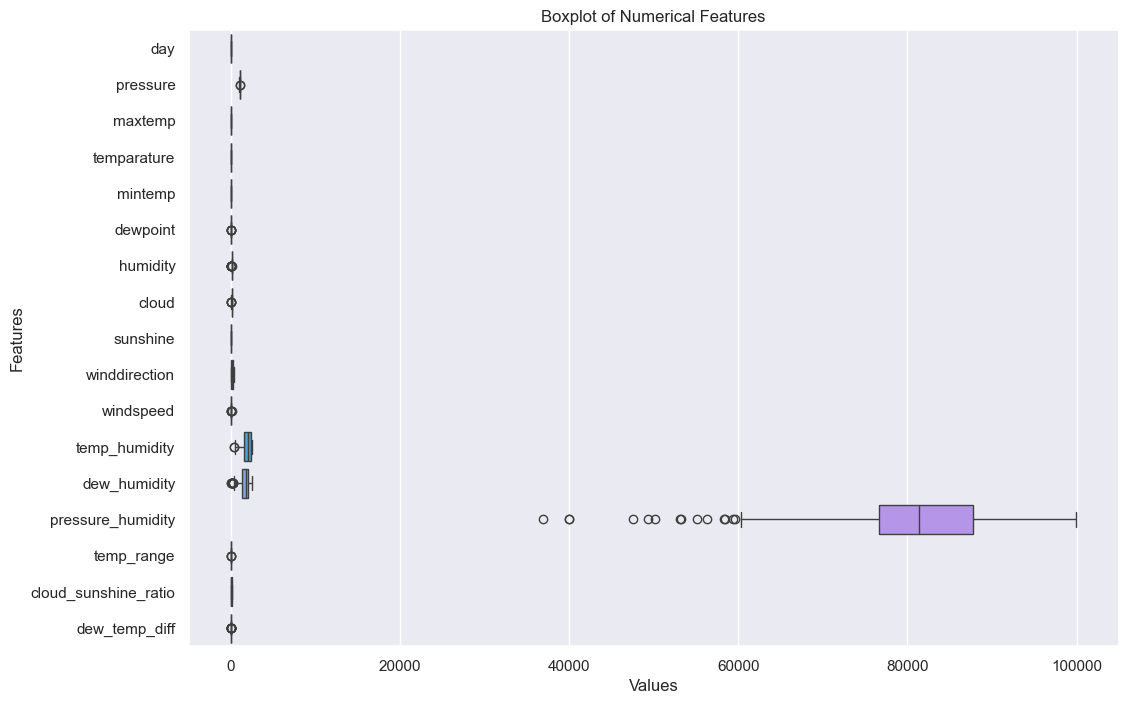

In [123]:
plt.figure(figsize=(12, 8))

sns.boxplot(rainfall.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

### `Winsorization` Replacing outlier with boundary values

In [124]:
for col in rainfall.select_dtypes(include=[np.number]):
    q1 = rainfall[col].quantile(0.25)
    q3 = rainfall[col].quantile(0.75)
    IQR = q3 -q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    rainfall[col] = rainfall[col].clip(lower_bound, upper_bound)

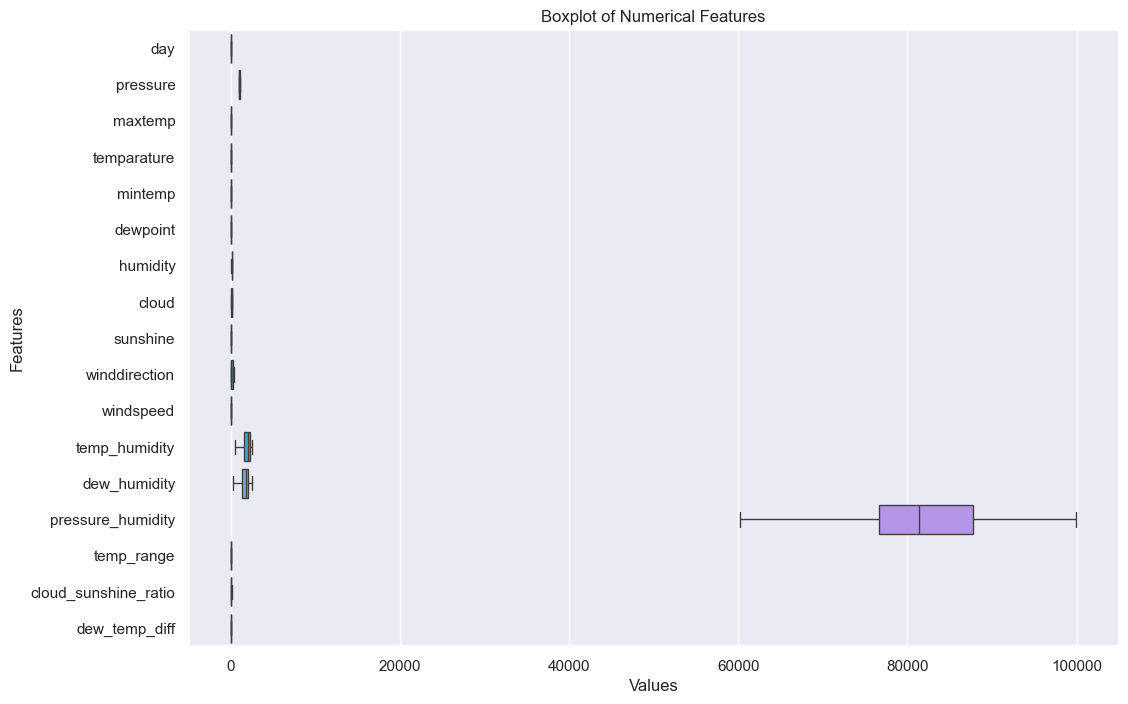

In [125]:
plt.figure(figsize=(12, 8))

sns.boxplot(rainfall.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

### `Data Visualization`

### `Pie chart` distribution on target variable

In [126]:
target_count = rainfall['rainfall'].value_counts()

print(target_count)

rainfall
yes    249
no     117
Name: count, dtype: int64


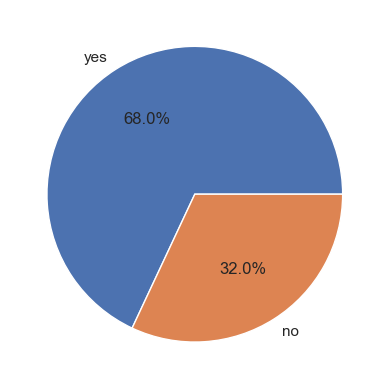

In [127]:
plt.pie(rainfall['rainfall'].value_counts().values,
        labels=rainfall['rainfall'].value_counts().index,
        autopct='%1.1f%%')

plt.show()

### `Subplot` distribution of Numerical Features

In [128]:
features = list(rainfall.select_dtypes(include=[np.number]).columns)
features.remove('day')
print(features)

['pressure', 'maxtemp', 'temparature', 'mintemp', 'dewpoint', 'humidity', 'cloud', 'sunshine', 'winddirection', 'windspeed', 'temp_humidity', 'dew_humidity', 'pressure_humidity', 'temp_range', 'cloud_sunshine_ratio', 'dew_temp_diff']


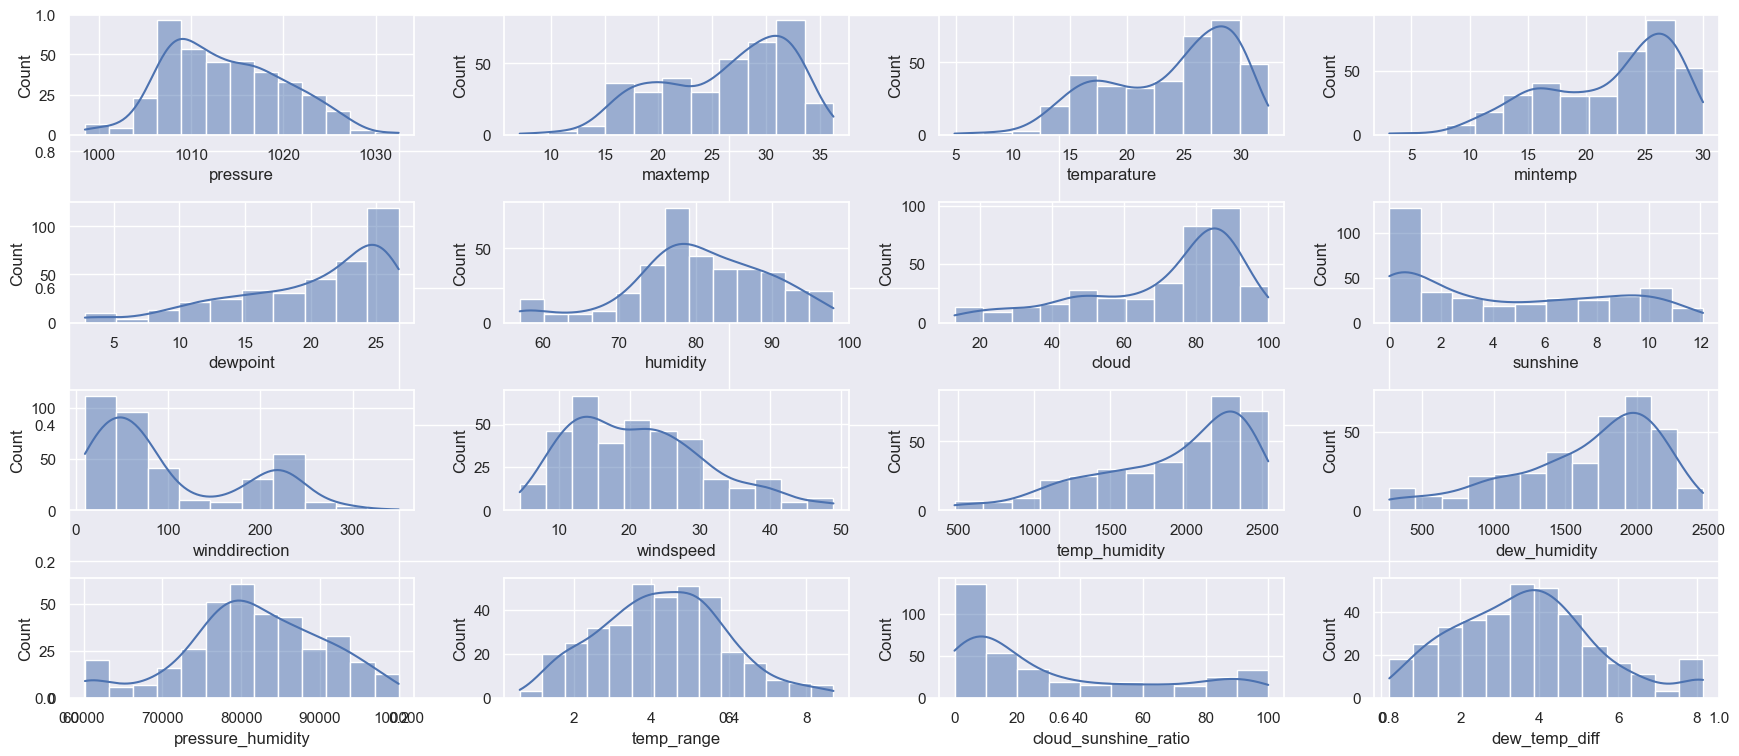

In [129]:
plt.subplots(figsize=(18, 8))

for i, col in enumerate(features):
    plt.subplot(4, 4, i + 1)
    sns.histplot(rainfall[col], kde=True)
plt.tight_layout()
plt.show()

### `Correlation` Heatmap

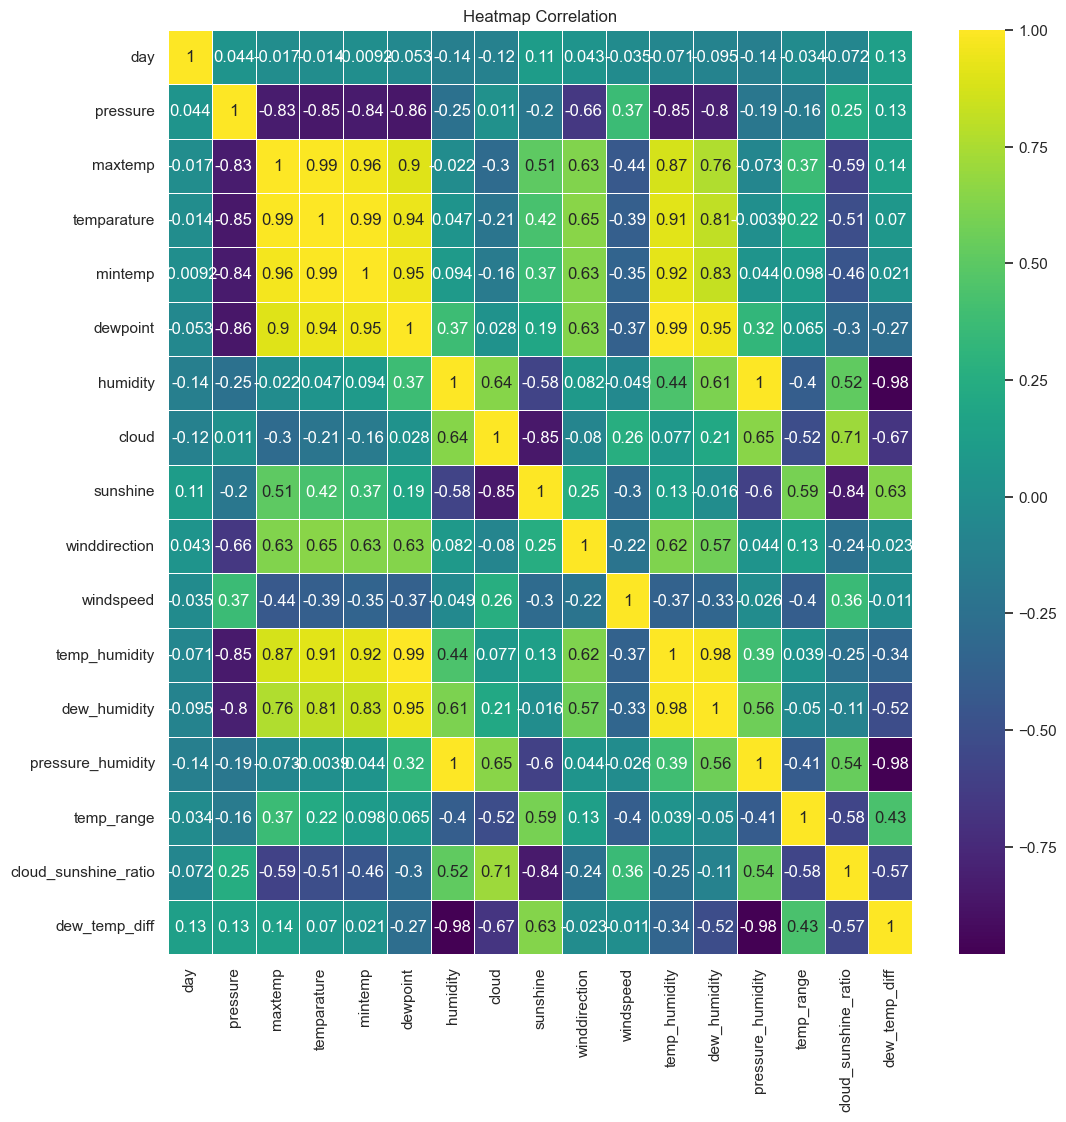

In [130]:
correlation = rainfall.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(12, 12))
sns.heatmap(correlation, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Heatmap Correlation')
plt.show()

## `Feature Encoding`

`Encoding` Target variable for Model Training and Evaluation using `Mapping` funtion since its a binary classification

In [131]:
rainfall['rainfall'] = rainfall['rainfall'].map({'yes' : 1, 'no' : 0})

In [132]:
rainfall.head()

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed,temp_humidity,dew_humidity,pressure_humidity,temp_range,cloud_sunshine_ratio,dew_temp_diff
0,1.0,1025.9,19.9,18.3,16.8,13.1,72.0,49.0,1,9.3,80.0,26.3,1317.6,943.2,73864.8,3.1,4.757282,5.2
1,2.0,1022.0,21.7,18.9,17.2,15.6,81.0,83.0,1,0.6,50.0,15.3,1530.9,1263.6,82782.0,4.5,51.875000,3.3
2,3.0,1019.7,20.3,19.3,18.0,18.4,95.0,91.0,1,0.0,40.0,14.2,1833.5,1748.0,96871.5,2.3,91.000000,0.9
3,4.0,1018.9,22.3,20.6,19.1,18.8,90.0,88.0,1,1.0,50.0,16.9,1854.0,1692.0,91701.0,3.2,44.000000,1.8
4,5.0,1015.9,21.3,20.7,20.2,19.9,95.0,81.0,1,0.0,40.0,13.7,1966.5,1890.5,96510.5,1.1,81.000000,0.8


## `Feature Selection` and `Data Splitting`

In [133]:
X = rainfall.drop(['rainfall', 'day'], axis=1)
y = rainfall['rainfall']

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [135]:
X_train.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,temp_humidity,dew_humidity,pressure_humidity,temp_range,cloud_sunshine_ratio,dew_temp_diff
341,1023.1,19.3,17.3,15.4,12.1,72.0,86.0,0.9,10.0,21.8,1245.6,871.2,73663.2,3.9,45.263158,5.2
202,1010.9,33.3,30.0,27.5,25.3,76.0,49.0,8.8,220.0,12.3,2280.0,1922.8,76828.4,5.8,5.000000,4.7
75,1015.0,16.3,15.3,14.1,13.6,90.0,100.0,0.0,60.0,33.2,1377.0,1224.0,91350.0,2.2,100.000000,1.7
84,1023.9,15.7,13.7,11.6,9.2,75.0,88.0,0.2,20.0,19.4,1027.5,690.0,76792.5,4.1,73.333333,4.5
354,1022.5,18.6,17.6,17.0,12.9,75.0,88.0,0.0,40.0,19.0,1320.0,967.5,76687.5,1.6,88.000000,4.7


In [136]:
X_test.head()

,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,sunshine,winddirection,windspeed,temp_humidity,dew_humidity,pressure_humidity,temp_range,cloud_sunshine_ratio,dew_temp_diff
193,1003.8,29.0,28.1,27.0,25.1,84.0,88.0,0.0,230.0,16.3,2360.4,2108.4,84319.2,2.0,88.000000,3.0
33,1023.6,14.3,12.5,10.3,8.6,77.0,88.0,0.3,40.0,21.3,962.5,662.2,78817.2,4.0,67.692308,3.9
15,1013.5,17.1,16.4,15.5,15.6,95.0,93.0,0.0,60.0,40.0,1558.0,1482.0,96282.5,1.6,93.000000,0.8
310,1015.6,26.3,25.5,24.7,22.4,83.0,81.0,0.5,80.0,30.2,2116.5,1859.2,84294.8,1.6,54.000000,3.1
57,1024.7,17.5,15.5,13.8,11.7,79.0,79.0,5.0,20.0,9.1,1224.5,924.3,80951.3,3.7,13.166667,3.8


In [137]:
y_train.head()

341    0
202    1
75     1
84     1
354    1
Name: rainfall, dtype: int64

In [138]:
y_test.head()

193    1
33     1
15     1
310    1
57     1
Name: rainfall, dtype: int64

### `Model Training, Prediction and Evaluation`

### `Logistic Regression`

In [139]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', random_state=42))
])

lr_pipe.fit(X_train, y_train)
lr_y_pred = lr_pipe.predict(X_test)
print(lr_y_pred)

[1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 0 0 0 1 1 1 1 0 1 1 0
 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 0]


`Model Accuracy`

In [140]:
accuracy = accuracy_score(y_test, lr_y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.77


`Model Prediction Probabilities`

In [141]:
lr_y_prob = lr_pipe.predict_proba(X_test)[:, 1]
print(f'\n ===== Prediction Probabilities ===== \n{lr_y_prob}')


 ===== Prediction Probabilities ===== 
[0.97916776 0.69381539 0.95456918 0.90721526 0.15629804 0.91030972
 0.95873025 0.35474324 0.67958236 0.80634456 0.9683566  0.01375741
 0.32723514 0.78909324 0.93395196 0.14653294 0.03755894 0.82317053
 0.71907861 0.97681529 0.94307963 0.90250306 0.96083351 0.24570099
 0.1063038  0.97426511 0.19072672 0.45590345 0.00368593 0.5771804
 0.60074574 0.89021834 0.861082   0.26195178 0.7339751  0.81080444
 0.40659246 0.88235843 0.91849668 0.07548903 0.97612027 0.91757805
 0.90399026 0.64172762 0.95413026 0.25649426 0.52542744 0.76616652
 0.12257786 0.89129073 0.54551599 0.33376593 0.94980587 0.4811393
 0.18425066 0.83488682 0.81396484 0.82465909 0.71032039 0.97011627
 0.07020768 0.63748635 0.8614715  0.5779162  0.54009416 0.59103376
 0.63606283 0.83656245 0.0697028  0.91748898 0.84021834 0.93025112
 0.69834108 0.21383094]


`Classification Report`

In [142]:
print(classification_report(y_test, lr_y_pred))

              precision    recall  f1-score   support

           0       0.64      0.61      0.62        23
           1       0.83      0.84      0.83        51

    accuracy                           0.77        74
   macro avg       0.73      0.73      0.73        74
weighted avg       0.77      0.77      0.77        74



In [143]:
ras = roc_auc_score(y_test, lr_y_prob)
print('Roc Auc Score: ', ras)

Roc Auc Score:  0.8218243819266836


`RocCurveDisplay`

In [144]:
for i, cls in enumerate(lr_pipe.classes_):
    print(f'Class {cls}: {lr_y_prob[i]:.4f}')

Class 0: 0.9792
Class 1: 0.6938


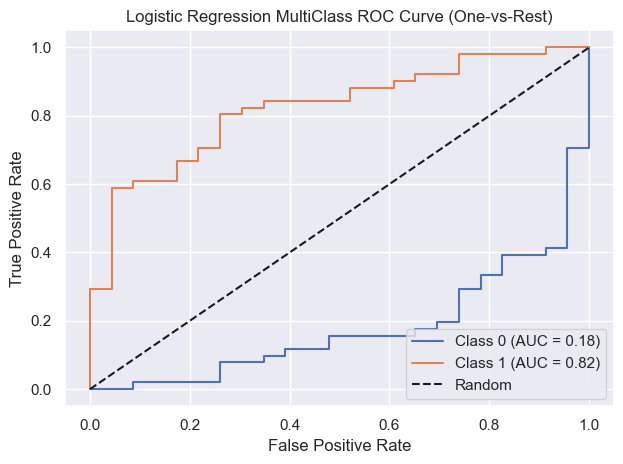

In [145]:
for i, cls in enumerate(lr_pipe.classes_):
    fpr, tpr, thresholds = roc_curve(y_test, lr_pipe.predict_proba(X_test)[:, i])
    lr_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {lr_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Logistic Regression MultiClass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

`Cross Validation`

In [146]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_pipe, X, y, cv=skf, scoring='roc_auc')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.89916667 0.90608696 0.90521739 0.87652174 0.80782313]
Mean Cross-Validation Accuracy: 0.879 (+/- 0.074)


### `Confusion Matrix`

Confusion Matrix:
 [[14  9]
 [ 8 43]]


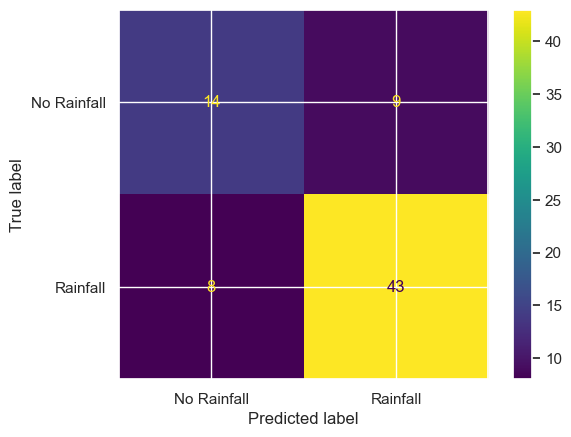

In [147]:
cm = confusion_matrix(y_test, lr_y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `RandomForestClassifier`

In [148]:
rfc = RandomForestClassifier(class_weight='balanced', random_state=42)

rfc.fit(X_train, y_train)
rfc_y_pred = rfc.predict(X_test)
print(rfc_y_pred)

[1 1 1 1 0 1 1 0 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 1 1 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1]


`Model Accuracy`

In [149]:
accuracy = accuracy_score(y_test, rfc_y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.74


`Prediction Probabilities`

In [150]:
rfc_y_prob = rfc.predict_proba(X_test)[:, 1]
print(f'\n ===== Prediction Probabilities ===== \n{rfc_y_prob}')


 ===== Prediction Probabilities ===== 
[0.91 0.94 1.   0.97 0.46 0.95 1.   0.44 0.89 0.81 0.99 0.   0.48 0.92
 0.76 0.38 0.34 0.78 0.92 0.98 1.   0.98 0.98 0.42 0.13 0.98 0.53 0.47
 0.06 0.45 0.78 0.94 0.83 0.71 0.94 0.84 0.67 0.93 0.96 0.23 0.97 0.96
 0.99 0.74 0.99 0.56 0.45 0.91 0.32 0.95 0.76 0.62 0.65 0.59 0.36 0.74
 0.65 0.86 0.63 0.91 0.12 0.45 0.78 0.83 0.89 0.91 0.75 0.9  0.12 0.93
 0.64 0.97 0.68 0.61]


`Classification Report`

In [151]:
print(classification_report(y_test, rfc_y_pred))

              precision    recall  f1-score   support

           0       0.61      0.48      0.54        23
           1       0.79      0.86      0.82        51

    accuracy                           0.74        74
   macro avg       0.70      0.67      0.68        74
weighted avg       0.73      0.74      0.73        74



In [152]:
ras = roc_auc_score(y_test, rfc_y_prob)
print('Roc Auc Score: ', ras)

Roc Auc Score:  0.8013640238704177


`RocCurveDisplay`

In [153]:
for i, cls in enumerate(rfc.classes_):
    print(f'Class {cls}: {rfc_y_prob[i]:.4f}')

Class 0: 0.9100
Class 1: 0.9400


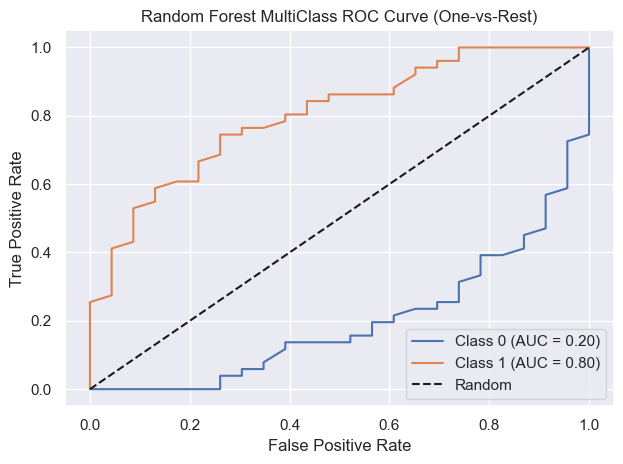

In [154]:
for i, cls in enumerate(rfc.classes_):
    fpr, tpr, thresholds = roc_curve(y_test, rfc.predict_proba(X_test)[:, i])
    rfc_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {rfc_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest MultiClass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

`Cross Validation`

In [155]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rfc, X, y, cv=skf, scoring='roc_auc')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.87125    0.87608696 0.86478261 0.83434783 0.7797619 ]
Mean Cross-Validation Accuracy: 0.845 (+/- 0.072)


### `Confusion Matrix`

Confusion Matrix:
 [[11 12]
 [ 7 44]]


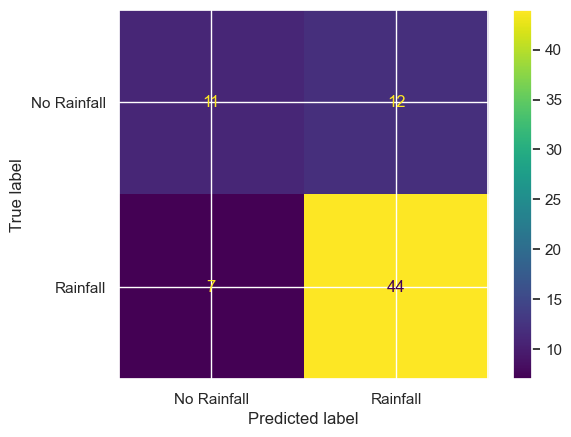

In [156]:
cm = confusion_matrix(y_test, rfc_y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `DecisionTreeClassifier`

In [157]:
dtc = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dtc.fit(X_train, y_train)
dtc_y_pred = dtc.predict(X_test)

In [158]:
print(dtc_y_pred)

[1 1 1 1 1 1 1 0 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 0 0 1 1 0 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1]


`Model Accuracy`

In [159]:
accuracy = accuracy_score(y_test, dtc_y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.68


`Classification Report`

In [160]:
print(classification_report(y_test, dtc_y_pred))

              precision    recall  f1-score   support

           0       0.48      0.43      0.45        23
           1       0.75      0.78      0.77        51

    accuracy                           0.68        74
   macro avg       0.62      0.61      0.61        74
weighted avg       0.67      0.68      0.67        74



In [161]:
ras = roc_auc_score(y_test, dtc_y_pred)

print('Roc Auc Score: ', ras)

Roc Auc Score:  0.6095481670929241


`RocCurveDisplay`

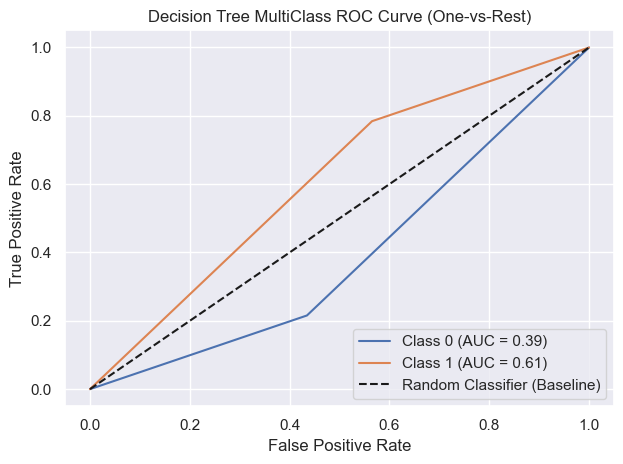

In [162]:
for i, cls in enumerate(dtc.classes_):
    fpr, tpr, thresholds = roc_curve(y_test, dtc.predict_proba(X_test)[:, i])
    dtc_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {dtc_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (Baseline)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree MultiClass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

`Cross Validation`

In [163]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(dtc, X, y, cv=skf, scoring='roc_auc')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.71166667 0.65086957 0.76608696 0.65086957 0.70960884]
Mean Cross-Validation Accuracy: 0.698 (+/- 0.087)


### `Confusion Matrix`

Confusion Matrix:
 [[10 13]
 [11 40]]


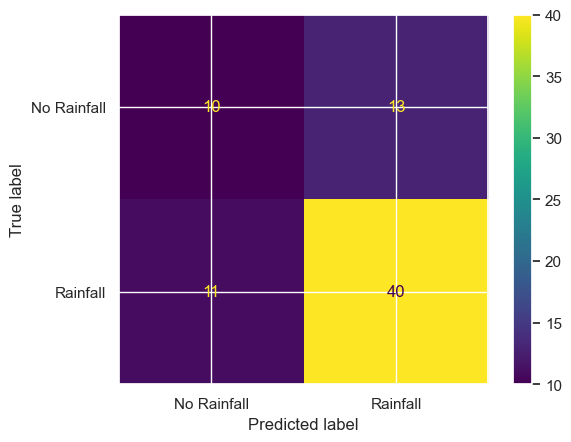

In [164]:
cm = confusion_matrix(y_test, dtc_y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

### `XGBClassifier`

In [165]:
xgb = XGBClassifier(class_weight='balanced', random_state=42)

xgb.fit(X_train, y_train)
xgb_y_pred = xgb.predict(X_test)

print(xgb_y_pred)

[1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 1 1 1 1
 1 1 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1]


`Model Accuracy`

In [166]:
accuracy = accuracy_score(y_test, xgb_y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.72


`Classification Report`

In [167]:
print(classification_report(y_test, xgb_y_pred))

              precision    recall  f1-score   support

           0       0.55      0.48      0.51        23
           1       0.78      0.82      0.80        51

    accuracy                           0.72        74
   macro avg       0.66      0.65      0.66        74
weighted avg       0.71      0.72      0.71        74



In [168]:
ras = roc_auc_score(y_test, xgb_y_pred)

print('Roc Auc Score: ', ras)

Roc Auc Score:  0.6508951406649617


`RocCurveDisplay`

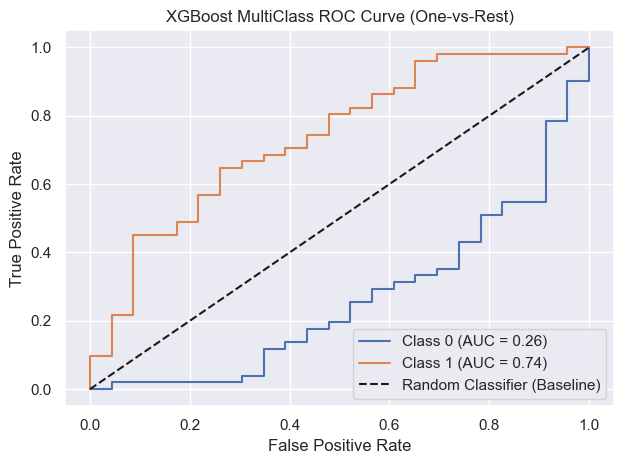

In [169]:
for i, cls in enumerate(xgb.classes_):
    fpr, tpr, thresholds = roc_curve(y_test, xgb.predict_proba(X_test)[:, i])
    xgb_roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {cls} (AUC = {xgb_roc_auc:.2f})')

plt.plot([0, 1], [0, 1], "k--", label="Random Classifier (Baseline)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost MultiClass ROC Curve (One-vs-Rest)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

`Cross Validation`

In [170]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=skf, scoring='roc_auc')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.88583333 0.84173913 0.84347826 0.80956522 0.76360544]
Mean Cross-Validation Accuracy: 0.829 (+/- 0.081)


### `Confusion Matrix`

Confusion Matrix:
 [[11 12]
 [ 9 42]]


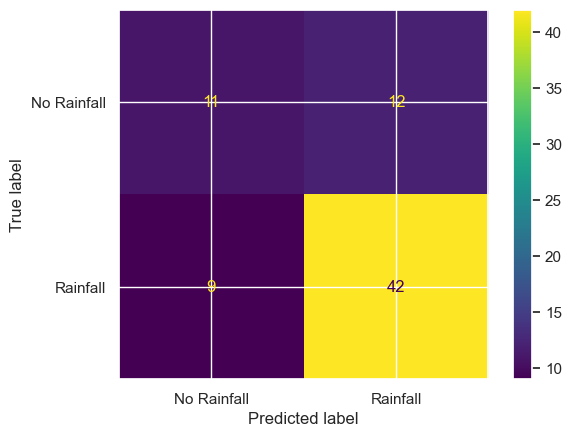

In [171]:
cm = confusion_matrix(y_test, xgb_y_pred)
print('Confusion Matrix:\n', cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rainfall', 'Rainfall'])
disp.plot()
plt.show()

## `Tuning Hyperparameter`

Tuning hyperparameter on `Scaled Logistic Regression`

### Using `RandomizedSearchCV`

In [172]:
param_dist = {
    'lr__C': [0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver': ['liblinear', 'saga'],
    'lr__max_iter': [200, 300, 400]
}

random = RandomizedSearchCV(
    estimator=lr_pipe, 
    param_distributions=param_dist, 
    n_iter=20,
    cv=5, 
    scoring='accuracy', 
    n_jobs=1,
    random_state=42,
    verbose=1
)

random.fit(X_train, y_train)


print('Best Param: ', random.best_params_)
print('Best CV Score: ', random.best_score_, 4)


# Evaluate on test set

lr_y_pred = random.predict(X_test)
print('\nTest Set Report:')
print(classification_report(y_test, lr_y_pred))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Param:  {'lr__solver': 'saga', 'lr__penalty': 'l1', 'lr__max_iter': 200, 'lr__C': 0.1}
Best CV Score:  0.8118059614260666 4

Test Set Report:
              precision    recall  f1-score   support

           0       0.61      0.48      0.54        23
           1       0.79      0.86      0.82        51

    accuracy                           0.74        74
   macro avg       0.70      0.67      0.68        74
weighted avg       0.73      0.74      0.73        74



Tuning hyperparameter on  `RandomForestClassifier`

### Using `RandomizedSearchCV`

In [173]:
param_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

random = RandomizedSearchCV(
    estimator=rfc, 
    param_distributions=param_grid, 
    n_iter=20,
    cv=5, 
    scoring='accuracy', 
    random_state=42,
    n_jobs=1,
)

random.fit(X_train, y_train)

print('Best Param: ', random.best_params_)
print('Best CV Score: ', random.best_score_, 4)

# Evaluate on test set
rfc_y_pred = random.predict(X_test)
print('\nTest Set Report:')
print(classification_report(y_test, rfc_y_pred))

Best Param:  {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Score:  0.8219754529514903 4

Test Set Report:
              precision    recall  f1-score   support

           0       0.55      0.48      0.51        23
           1       0.78      0.82      0.80        51

    accuracy                           0.72        74
   macro avg       0.66      0.65      0.66        74
weighted avg       0.71      0.72      0.71        74

